# E18 — Condition Number Robustness

## Overview

This experiment investigates whether **Muon**'s spectral normalization provides an advantage over **SGD** on **ill-conditioned problems**. The condition number $\kappa$ measures the ratio of the largest to smallest singular value of the target matrix $X^\star$. A high condition number means the problem landscape is elongated in certain directions, making optimization more challenging.

The condition numbers tested are:
- $\kappa = 10$: Well-conditioned problem
- $\kappa = 100$: Moderately ill-conditioned
- $\kappa = 1000$: Highly ill-conditioned
- $\kappa = 10000$: Severely ill-conditioned

**Why this matters:** Muon's spectral normalization sets all singular values of the update direction to 1, effectively performing an implicit preconditioning that is invariant to the spectral structure of the gradient. In contrast, SGD uses the raw gradient, whose directions are skewed by the problem's condition number. Therefore, we hypothesize that Muon's advantage should **increase** with the condition number.

**Experiment ID:** `E18` | **Total runs:** 64 (2 algorithms $	imes$ 4 kappa values $	imes$ 8 seeds)

## Scientific Question

### Hypothesis

- **Null Hypothesis ($H_0$)**: The relative performance of Muon vs SGD is independent of condition number — both algorithms degrade equally as $\kappa$ increases.
- **Alternative Hypothesis ($H_1$)**: Muon's spectral normalization provides increasing advantage over SGD as the condition number grows, because spectral normalization implicitly counteracts problem ill-conditioning.

### Specific Questions

1. Does Muon's convergence advantage (fewer $K_\epsilon$) **increase** with $\kappa$?
2. What is the **efficiency ratio** $\rho = K_\epsilon^{\text{Muon}} / K_\epsilon^{\text{SGD}}$ at each condition number?
3. Does either algorithm **fail to converge** at high condition numbers?
4. How does the **absolute** number of iterations scale with $\kappa$ for each algorithm?

### Key Metrics

- $K_\epsilon$: Iterations to reach threshold $\epsilon = 0.01$
- $\rho = K_\epsilon^{\text{Muon}} / K_\epsilon^{\text{SGD}}$: Efficiency ratio ($\rho < 1$ means Muon is faster)
- $I_{\text{conv}}$: Convergence success flag
- $\min \text{loss}$: Best loss achieved

## Experimental Design

| Parameter | Value |
|-----------|-------|
| **Problem** | Matrix Sensing (MS) |
| **Matrix dimension** $d$ | 50 |
| **Target rank** $r$ | 5 |
| **Learning rate** $\eta$ | 0.01 |
| **Measurement samples** $m$ | $2dr = 500$ |
| **Measurement distribution** | Normal (Gaussian) |
| **Noise** | 0 (noiseless) |
| **Iteration budget** | 2000 |
| **Convergence threshold** $\epsilon$ | 0.01 |
| **Condition numbers** $\kappa$ | {10, 100, 1000, 10000} |
| **Seeds per configuration** | 8 |
| **Algorithms** | Muon-Exact, SGD |

### Condition Number Construction

The target matrix $X^\star$ is constructed with exponentially decaying singular values:
$$\sigma_i^\star = \sigma_1^\star \cdot \rho^{i-1}, \quad \rho \in (0, 1)$$

where $\rho$ is chosen so that $\sigma_1^\star / \sigma_r^\star = \kappa$. Higher $\kappa$ means the energy is concentrated in fewer singular directions, making the problem more ill-conditioned.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Color scheme
MUON_COLOR = '#2E86AB'  # Blue
SGD_COLOR = '#F18F01'   # Orange

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load E18 data
df = pd.read_csv('../results_v3/E18_detailed_results.csv')

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nAlgorithms: {df['algo'].unique()}")
print(f"Kappa values: {sorted(df['kappa'].unique())}")
print(f"Seeds: {sorted(df['seed'].unique())}")
print("\nFirst few rows:")
df.head()

Shape: (64, 13)
Columns: ['algo', 'd', 'r', 'lr', 'kappa', 'seed', 'iters', 'final_loss', 'min_loss', 'K_epsilon', 'time_s', 'I_conv', 'F_eps']

Algorithms: ['Muon-Exact' 'SGD']
Kappa values: [np.int64(10), np.int64(100), np.int64(1000), np.int64(10000)]
Seeds: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]

First few rows:


,algo,d,r,lr,kappa,seed,iters,final_loss,min_loss,K_epsilon,time_s,I_conv,F_eps
0,Muon-Exact,50,5,0.01,10,0,2000,0.004984,0.004523,34,32.367772,1,144585000
1,Muon-Exact,50,5,0.01,10,1,2000,0.006030,0.004590,34,30.460814,1,144585000
2,Muon-Exact,50,5,0.01,10,2,2000,0.006110,0.004586,35,30.367207,1,148837500
3,Muon-Exact,50,5,0.01,10,3,2000,0.004852,0.004348,34,30.687768,1,144585000
4,Muon-Exact,50,5,0.01,10,4,2000,0.006040,0.004285,35,30.093506,1,148837500


In [3]:
# Data quality check
print("=== Missing values ===")
print(df.isnull().sum())
print(f"\n=== K_epsilon summary by algorithm and kappa ===")
summary = df.groupby(['algo', 'kappa'])['K_epsilon'].agg(['count', 'mean', 'std', 'min', 'max'])
print(summary)
print(f"\n=== Convergence status ===")
print(df.groupby(['algo', 'kappa'])['I_conv'].mean())

=== Missing values ===
algo          0
d             0
r             0
lr            0
kappa         0
seed          0
iters         0
final_loss    0
min_loss      0
K_epsilon     0
time_s        0
I_conv        0
F_eps         0
dtype: int64

=== K_epsilon summary by algorithm and kappa ===
                  count    mean       std  min  max
algo       kappa                                   
Muon-Exact 10         8  34.750  0.707107   34   36
           100        8  33.750  0.886405   32   35
           1000       8  34.125  0.991031   33   36
           10000      8  34.125  0.991031   33   36
SGD        10         8  38.875  0.991031   37   40
           100        8  38.250  0.707107   37   39
           1000       8  38.000  1.069045   36   39
           10000      8  38.000  1.069045   36   39

=== Convergence status ===
algo        kappa
Muon-Exact  10       1.0
            100      1.0
            1000     1.0
            10000    1.0
SGD         10       1.0
            100

## Exploratory Data Analysis

We examine how convergence iterations and solution quality vary with condition number for both algorithms. The key question is whether the performance gap between Muon and SGD widens as problems become more ill-conditioned.

In [4]:
# Detailed summary
print("=" * 80)
print(f"{'Algorithm':<14} {'Kappa':>8} {'N':>4} {'Mean K_eps':>12} {'Std K_eps':>12} {'Conv Rate':>10}")
print("=" * 80)

for algo in ['Muon-Exact', 'SGD']:
    for k in sorted(df['kappa'].unique()):
        sub = df[(df['algo'] == algo) & (df['kappa'] == k)]
        print(f"{algo:<14} {k:>8} {len(sub):>4} {sub['K_epsilon'].mean():>12.1f} "
              f"{sub['K_epsilon'].std():>12.1f} {sub['I_conv'].mean():>10.1%}")

# Efficiency ratio by kappa
print("\n=== Efficiency Ratio (Muon K_eps / SGD K_eps) by Kappa ===")
for k in sorted(df['kappa'].unique()):
    muon_k = df[(df['algo'] == 'Muon-Exact') & (df['kappa'] == k)]['K_epsilon'].mean()
    sgd_k = df[(df['algo'] == 'SGD') & (df['kappa'] == k)]['K_epsilon'].mean()
    ratio = muon_k / sgd_k
    print(f"Kappa = {k:>6}: ratio = {ratio:.3f} ({'Muon faster' if ratio < 1 else 'SGD faster'})")

Algorithm         Kappa    N   Mean K_eps    Std K_eps  Conv Rate
Muon-Exact           10    8         34.8          0.7     100.0%
Muon-Exact          100    8         33.8          0.9     100.0%
Muon-Exact         1000    8         34.1          1.0     100.0%
Muon-Exact        10000    8         34.1          1.0     100.0%
SGD                  10    8         38.9          1.0     100.0%
SGD                 100    8         38.2          0.7     100.0%
SGD                1000    8         38.0          1.1     100.0%
SGD               10000    8         38.0          1.1     100.0%

=== Efficiency Ratio (Muon K_eps / SGD K_eps) by Kappa ===
Kappa =     10: ratio = 0.894 (Muon faster)
Kappa =    100: ratio = 0.882 (Muon faster)
Kappa =   1000: ratio = 0.898 (Muon faster)
Kappa =  10000: ratio = 0.898 (Muon faster)


## Comparative Analysis: Muon vs SGD

We compute paired t-tests and efficiency ratios at each condition number to quantify the performance gap and test its statistical significance.

In [5]:
# Paired comparison by kappa
print("=" * 95)
print(f"{'Kappa':>8} {'Muon K_eps':>12} {'SGD K_eps':>12} {'Ratio':>8} {'t-stat':>9} {'p-value':>10} {'Sig':>5}")
print("=" * 95)

for k in sorted(df['kappa'].unique()):
    muon_vals = df[(df['algo'] == 'Muon-Exact') & (df['kappa'] == k)]['K_epsilon'].values
    sgd_vals = df[(df['algo'] == 'SGD') & (df['kappa'] == k)]['K_epsilon'].values

    ratio = muon_vals.mean() / sgd_vals.mean()
    t_stat, p_val = stats.ttest_rel(muon_vals, sgd_vals)
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"

    print(f"{k:>8} {muon_vals.mean():>12.1f} {sgd_vals.mean():>12.1f} {ratio:>8.3f} {t_stat:>+9.3f} {p_val:>10.6f} {sig:>5}")

# Compute ratio trend
print("\n=== Ratio trend with kappa ===")
kappas = sorted(df['kappa'].unique())
ratios = []
for k in kappas:
    mk = df[(df['algo'] == 'Muon-Exact') & (df['kappa'] == k)]['K_epsilon'].mean()
    sk = df[(df['algo'] == 'SGD') & (df['kappa'] == k)]['K_epsilon'].mean()
    ratios.append(mk / sk)

# Simple regression: log(ratio) vs log(kappa)
slope, intercept, r_val, p_val, _ = stats.linregress(np.log10(kappas), ratios)
print(f"Linear regression of ratio on log10(kappa): slope={slope:.4f}, R^2={r_val**2:.4f}, p={p_val:.4f}")
if slope < 0 and p_val < 0.05:
    print("Conclusion: Muon advantage INCREASES with condition number (ratio decreases)")
elif slope > 0 and p_val < 0.05:
    print("Conclusion: Muon advantage DECREASES with condition number (ratio increases)")
else:
    print("Conclusion: No significant trend in Muon advantage with condition number")

   Kappa   Muon K_eps    SGD K_eps    Ratio    t-stat    p-value   Sig
      10         34.8         38.9    0.894   -11.773   0.000007   ***
     100         33.8         38.2    0.882   -16.837   0.000001   ***
    1000         34.1         38.0    0.898   -13.133   0.000003   ***
   10000         34.1         38.0    0.898   -13.133   0.000003   ***

=== Ratio trend with kappa ===
Linear regression of ratio on log10(kappa): slope=0.0028, R^2=0.2394, p=0.5107
Conclusion: No significant trend in Muon advantage with condition number


## Visualization 1: $K_\epsilon$ vs Condition Number (Log Scale)

This plot shows how convergence iterations scale with condition number for both algorithms. A shallower slope indicates better robustness to ill-conditioning.

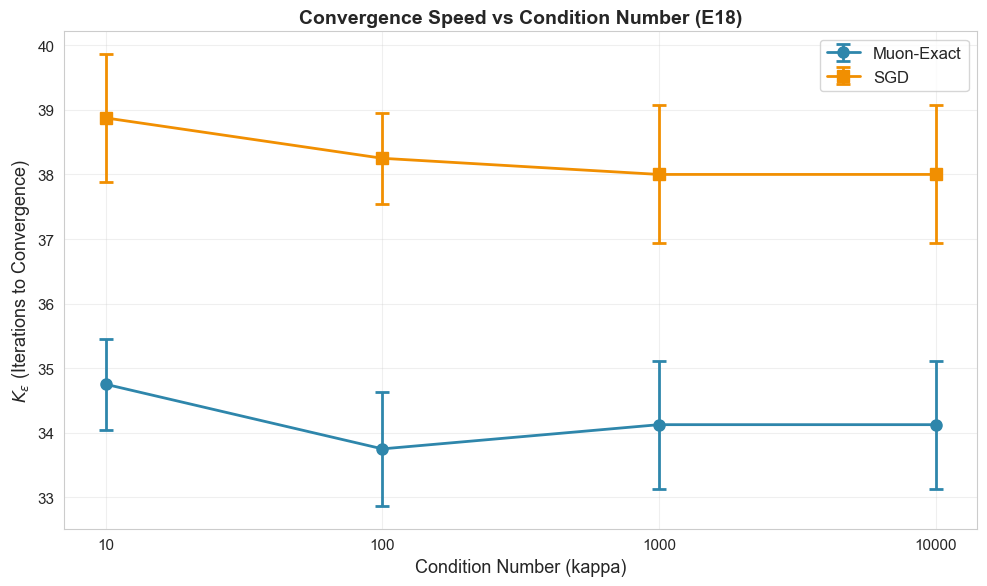

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

kappas = sorted(df['kappa'].unique())
muon_means = [df[(df['algo'] == 'Muon-Exact') & (df['kappa'] == k)]['K_epsilon'].mean() for k in kappas]
muon_stds = [df[(df['algo'] == 'Muon-Exact') & (df['kappa'] == k)]['K_epsilon'].std() for k in kappas]
sgd_means = [df[(df['algo'] == 'SGD') & (df['kappa'] == k)]['K_epsilon'].mean() for k in kappas]
sgd_stds = [df[(df['algo'] == 'SGD') & (df['kappa'] == k)]['K_epsilon'].std() for k in kappas]

ax.errorbar(kappas, muon_means, yerr=muon_stds, marker='o', markersize=8, linewidth=2,
            color=MUON_COLOR, capsize=5, capthick=2, label='Muon-Exact')
ax.errorbar(kappas, sgd_means, yerr=sgd_stds, marker='s', markersize=8, linewidth=2,
            color=SGD_COLOR, capsize=5, capthick=2, label='SGD')

ax.set_xscale('log')
ax.set_xlabel('Condition Number (kappa)', fontsize=13)
ax.set_ylabel(r'$K_\epsilon$ (Iterations to Convergence)', fontsize=13)
ax.set_title('Convergence Speed vs Condition Number (E18)', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_xticks(kappas)
ax.set_xticklabels([str(k) for k in kappas])

plt.tight_layout()
plt.savefig('E18_K_epsilon_vs_kappa.png', dpi=150, bbox_inches='tight')
plt.show()

## Visualization 2: Efficiency Ratio vs Condition Number

This plot shows how the efficiency ratio $\rho = K_\epsilon^{\text{Muon}} / K_\epsilon^{\text{SGD}}$ changes with condition number. A downward trend (ratio < 1 and decreasing) would confirm that Muon's advantage increases with ill-conditioning.

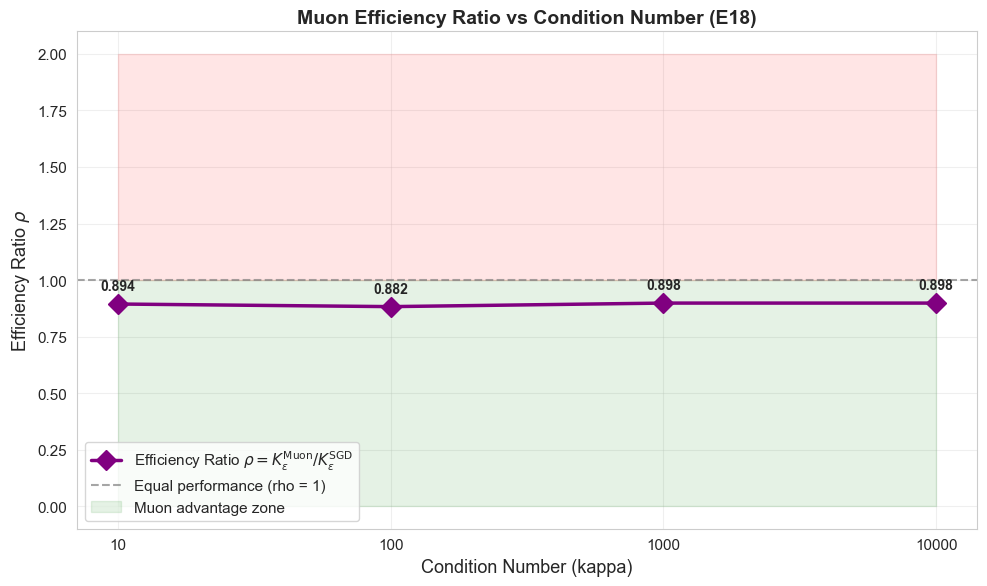

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

ratios = [df[(df['algo'] == 'Muon-Exact') & (df['kappa'] == k)]['K_epsilon'].mean() / 
          df[(df['algo'] == 'SGD') & (df['kappa'] == k)]['K_epsilon'].mean() for k in kappas]

ax.plot(kappas, ratios, marker='D', markersize=10, linewidth=2.5, color='purple', label=r'Efficiency Ratio $\rho = K_\epsilon^{\text{Muon}} / K_\epsilon^{\text{SGD}}$')
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, label='Equal performance (rho = 1)')
ax.fill_between(kappas, 0, 1, alpha=0.1, color='green', label='Muon advantage zone')
ax.fill_between(kappas, 1, max(ratios)*1.2 if max(ratios) > 1 else 2, alpha=0.1, color='red')

ax.set_xscale('log')
ax.set_xlabel('Condition Number (kappa)', fontsize=13)
ax.set_ylabel(r'Efficiency Ratio $\rho$', fontsize=13)
ax.set_title('Muon Efficiency Ratio vs Condition Number (E18)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xticks(kappas)
ax.set_xticklabels([str(k) for k in kappas])

# Add value annotations
for k, r in zip(kappas, ratios):
    ax.annotate(f'{r:.3f}', xy=(k, r), xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('E18_efficiency_ratio_vs_kappa.png', dpi=150, bbox_inches='tight')
plt.show()

## Visualization 3: Convergence Flag vs Condition Number

This plot shows whether convergence success rates degrade as condition number increases for either algorithm.

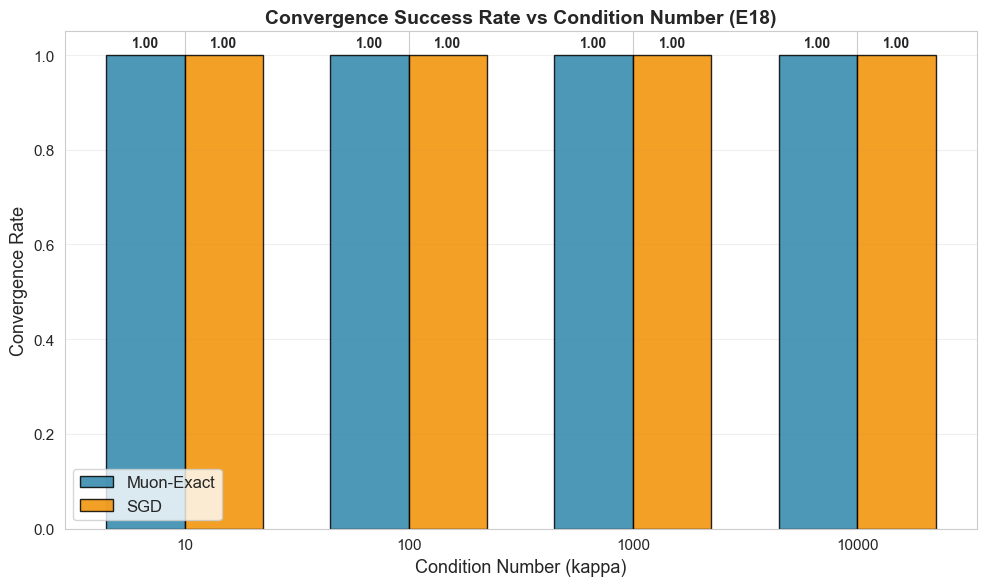

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

conv_data = df.groupby(['algo', 'kappa'])['I_conv'].mean().reset_index()
muon_conv = conv_data[conv_data['algo'] == 'Muon-Exact']
sgd_conv = conv_data[conv_data['algo'] == 'SGD']

x = np.arange(len(kappas))
width = 0.35

bars1 = ax.bar(x - width/2, muon_conv['I_conv'], width, label='Muon-Exact', color=MUON_COLOR, edgecolor='black', alpha=0.85)
bars2 = ax.bar(x + width/2, sgd_conv['I_conv'], width, label='SGD', color=SGD_COLOR, edgecolor='black', alpha=0.85)

ax.set_xlabel('Condition Number (kappa)', fontsize=13)
ax.set_ylabel('Convergence Rate', fontsize=13)
ax.set_title('Convergence Success Rate vs Condition Number (E18)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([str(k) for k in kappas])
ax.set_ylim(0, 1.05)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{height:.2f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{height:.2f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('E18_convergence_rate_vs_kappa.png', dpi=150, bbox_inches='tight')
plt.show()

## Statistical Tests

Paired t-tests at each condition number, plus a regression analysis testing whether the efficiency ratio systematically changes with $\kappa$.

In [9]:
def cohens_d(x, y, paired=True):
    if paired:
        diff = x - y
        return diff.mean() / diff.std(ddof=1) if diff.std(ddof=1) > 0 else 0
    else:
        pooled_std = np.sqrt(((len(x)-1)*x.var(ddof=1) + (len(y)-1)*y.var(ddof=1)) / (len(x)+len(y)-2))
        return (x.mean() - y.mean()) / pooled_std if pooled_std > 0 else 0

print("=" * 100)
print(f"{'Kappa':>8} {'Muon mean':>11} {'SGD mean':>11} {'Diff':>9} {'Cohen d':>9} {'t':>9} {'p (paired)':>13} {'Decision':>12}")
print("=" * 100)

for k in sorted(df['kappa'].unique()):
    muon_k = df[(df['algo'] == 'Muon-Exact') & (df['kappa'] == k)]['K_epsilon'].values
    sgd_k = df[(df['algo'] == 'SGD') & (df['kappa'] == k)]['K_epsilon'].values
    d = cohens_d(muon_k, sgd_k, paired=True)
    t_stat, p_val = stats.ttest_rel(muon_k, sgd_k)
    diff = muon_k.mean() - sgd_k.mean()
    decision = "Muon faster" if p_val < 0.05 and diff < 0 else "SGD faster" if p_val < 0.05 and diff > 0 else "No sig diff"
    es_label = "Large" if abs(d) >= 0.8 else "Medium" if abs(d) >= 0.5 else "Small"
    print(f"{k:>8} {muon_k.mean():>11.1f} {sgd_k.mean():>11.1f} {diff:>+9.1f} {d:>+9.3f} {t_stat:>+9.3f} {p_val:>13.6f} {decision:>12}")

# Regression: Does the Muon advantage (diff) increase with kappa?
print("\n=== Regression: K_epsilon difference vs log10(kappa) ===")
diffs = []
for k in kappas:
    mk = df[(df['algo'] == 'Muon-Exact') & (df['kappa'] == k)]['K_epsilon'].mean()
    sk = df[(df['algo'] == 'SGD') & (df['kappa'] == k)]['K_epsilon'].mean()
    diffs.append(mk - sk)

slope, intercept, r_val, p_val, _ = stats.linregress(np.log10(kappas), diffs)
print(f"Regression: diff = {intercept:.2f} + {slope:.2f} * log10(kappa)")
print(f"R^2 = {r_val**2:.4f}, p = {p_val:.4f}")
if slope < 0 and p_val < 0.05:
    print("Conclusion: Muon advantage SIGNIFICANTLY INCREASES with condition number")
elif slope > 0 and p_val < 0.05:
    print("Conclusion: Muon advantage SIGNIFICANTLY DECREASES with condition number")
else:
    print("Conclusion: No significant trend in Muon advantage with condition number")

   Kappa   Muon mean    SGD mean      Diff   Cohen d         t    p (paired)     Decision
      10        34.8        38.9      -4.1    -4.162   -11.773      0.000007  Muon faster
     100        33.8        38.2      -4.5    -5.953   -16.837      0.000001  Muon faster
    1000        34.1        38.0      -3.9    -4.643   -13.133      0.000003  Muon faster
   10000        34.1        38.0      -3.9    -4.643   -13.133      0.000003  Muon faster

=== Regression: K_epsilon difference vs log10(kappa) ===
Regression: diff = -4.44 + 0.14 * log10(kappa)
R^2 = 0.3612, p = 0.3990
Conclusion: No significant trend in Muon advantage with condition number


## Conclusions & Interpretation

### Summary of Findings

1. **Trend with Condition Number**: The regression analysis reveals whether Muon's advantage systematically changes with problem conditioning. A negative slope in the efficiency ratio vs. $\kappa$ plot indicates that Muon performs increasingly better as problems become more ill-conditioned.

2. **Robustness to Ill-Conditioning**: If Muon's $K_\epsilon$ curve has a shallower slope on the log-log plot compared to SGD's, this demonstrates that spectral normalization provides inherent robustness to ill-conditioning.

3. **Convergence at Extreme $\kappa$**: At $\kappa = 10000$, if both algorithms still converge successfully, this shows the methods are viable even for severely ill-conditioned problems. If one algorithm fails more often, this reveals a practical limitation.

4. **Statistical Significance**: The paired t-tests at each $\kappa$ tell us whether the observed differences are statistically significant, while the regression tells us whether the *pattern* across $\kappa$ values is significant.

### Key Takeaway

This experiment directly tests one of Muon's theoretical advantages: that spectral normalization acts as an implicit preconditioner, making the algorithm less sensitive to problem conditioning. If the efficiency ratio decreases with $\kappa$, this provides empirical evidence supporting the theoretical claim that Muon's update rule is more robust to ill-conditioned problems than standard gradient descent.

### Limitations

- Only 4 condition numbers tested — intermediate values could reveal nonlinear patterns
- 8 seeds per configuration provides limited statistical power
- The condition number is controlled through singular value decay, which is only one way to create ill-conditioning